# 노트북에서 FMNIST 모델 학습 및 서빙 API 생성 파이프라인 만들기

## 1. 라이브러리 추가 및 데이터 확인
- Fashion MNIST 데이터셋을 다운로드하고 간단하게 시각화하여 데이터 확인

/opt/conda/lib/python3.11/site-packages/pydantic/_internal/_config.py:373: UserWarning: Valid config keys have changed in V2:
* 'json_loads' has been removed
  warnings.warn(message, UserWarning)
INFO:matplotlib.font_manager:generated new fontManager


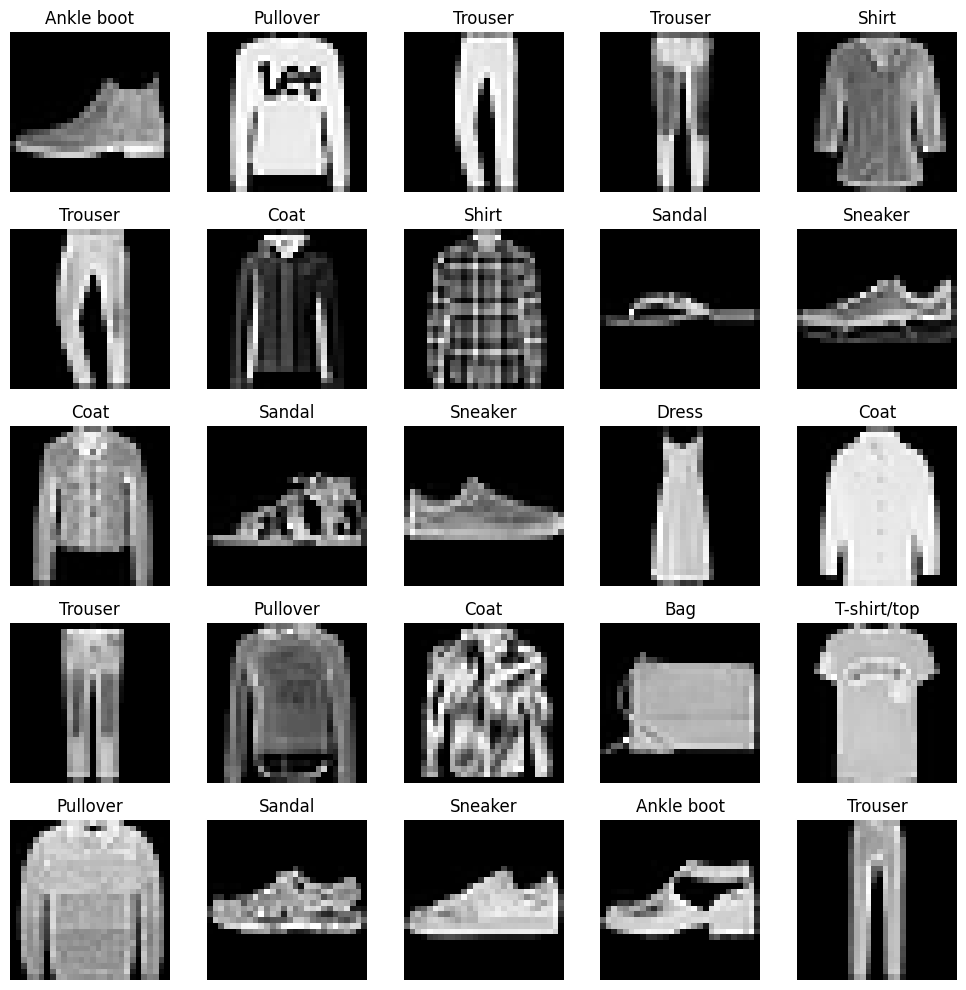

In [1]:
import requests
import os
import uuid
from pathlib import Path
from kakaocloud_kbm import KbmPipelineClient
import kfp.compiler as compiler
import kfp.dsl as dsl
from kfp import kubernetes, components
import gzip
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO

# Fashion MNIST 데이터셋 URL
t10k_images_url = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz'
t10k_labels_url = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz'

def download_and_extract(url):
    response = requests.get(url)
    with gzip.open(BytesIO(response.content), 'rb') as f:
        return np.frombuffer(f.read(), np.uint8)

t10k_images = download_and_extract(t10k_images_url)[16:].reshape(-1, 28, 28)
t10k_labels = download_and_extract(t10k_labels_url)[8:]

label_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def show_images(images, labels, label_names, rows=5, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    axes = axes.flatten()

    for img, ax, lbl in zip(images, axes, labels):
        ax.imshow(img, cmap='gray')
        ax.set_title(label_names[lbl])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_images(t10k_images[:25], t10k_labels[:25], label_names)


## 2. 환경 변수 설정

In [2]:
os.environ.setdefault("KUBEFLOW_HOST", "https://kakaocloud-edu.com")
os.environ.setdefault("KUBEFLOW_USERNAME", "hoi.7@kakaoenterprise.com")
os.environ.setdefault("KUBEFLOW_PASSWORD", "admin1234!")

# 환경변수들 준비
KBM_NAMESPACE = os.environ['NB_PREFIX'].split('/')[2]
TRAIN_PATH = 'fmnist_serve_model'
TRAIN_CR_IMAGE = "bigdata-150.kr-central-2.kcr.dev/kc-kubeflow/kmlp-pytorch:1.0.0.py36.cuda"
TASK_UUID = uuid.uuid1().hex[:8]
PVC_NAME = f"test-fmnist-pvc-{TASK_UUID}"
MODEL_NAME = f"torch-model-{TASK_UUID}"
KBM_MODEL_SERV_NAME = f"torchserve-{TASK_UUID}"
EPOCH_NUM = 1
RUNTIME_NAME = "fmnist-pytorch-foreground-runtime"

print(f"Namespace : {KBM_NAMESPACE}")
print(f"Train Path : {TRAIN_PATH}")
print(f"Image for Training : {TRAIN_CR_IMAGE}")
print(f"Model Name : {MODEL_NAME}")
print(f"Model PVC Name : {PVC_NAME}")
print(f"Model Server Name : {KBM_MODEL_SERV_NAME}")
print(f"Number of Epochs : {EPOCH_NUM}")
print(f"ServingRuntime Name : {RUNTIME_NAME}")

# 학습을 위한 폴더 생성
os.makedirs(TRAIN_PATH, exist_ok=True)

Namespace : kbm-u-kubeflow-tutorial
Train Path : fmnist_serve_model
Image for Training : bigdata-150.kr-central-2.kcr.dev/kc-kubeflow/kmlp-pytorch:1.0.0.py36.cuda
Model Name : torch-model-63e62460
Model PVC Name : test-fmnist-pvc-63e62460
Model Server Name : torchserve-63e62460
Number of Epochs : 1
ServingRuntime Name : fmnist-pytorch-foreground-runtime


## 3. 파이프라인 컴포넌트 빌드하기

### 3-1. 데이터셋 준비 컴포넌트: Fashion MNIST 데이터셋 다운로드 컴포넌트 정의

In [3]:
@dsl.component(
    base_image="python:3.11",
    packages_to_install=["requests"],
)
def download_fashion_mnist(
    t10k_images_url: str = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz',
    t10k_labels_url: str = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz',
    train_images_url: str = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz',
    train_labels_url: str = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-labels-idx1-ubyte.gz'
) -> str:
    import os
    import requests
    import gzip

    def download_and_save(url, output_path):
        response = requests.get(url, stream=True)
        with open(output_path, 'wb') as f:
            f.write(response.content)
        with gzip.open(output_path, 'rb') as f_in:
            with open(output_path.rstrip('.gz'), 'wb') as f_out:
                f_out.write(f_in.read())

    os.makedirs('/pvc', exist_ok=True)
    download_and_save(t10k_images_url, '/pvc/t10k-images-idx3-ubyte.gz')
    download_and_save(t10k_labels_url, '/pvc/t10k-labels-idx1-ubyte.gz')
    download_and_save(train_images_url, '/pvc/train-images-idx3-ubyte.gz')
    download_and_save(train_labels_url, '/pvc/train-labels-idx1-ubyte.gz')

    return '/pvc'

### 3-2. Fashion MNIST 모델 학습 및 서빙 구성
- Fashion MNIST 데이터를 사용해 CNN(Convolutional Neural Network) 모델을 학습시킴
- 학습된 모델과 관련된 여러 파일을 생성하는 작업을 수행
  - 학습된 모델 가중치 파일: fmnist_cnn.pth
  - TorchServe 핸들러 스크립트: 모델을 서빙하기 위한 핸들러 파일인 handler.py가 생성됨
  - TorchServe 설정 파일: 모델 서빙 환경을 설정하는 config.properties 파일이 생성됨
- handler.py: PyTorch 기반 모델을 TorchServe에서 서빙할 때 요청을 처리하는 역할을 수행
  - 파일처음 요청이 들어왔을 때 모델을 초기화함.
  - 데이터가 들어오면, 순차적으로 전처리(preprocess) -> 추론(inference) -> 후처리(postprocess) 단계를 거치며 결과를 반환함.
    - 전처리: 입력으로 받은 데이터를 처리하여 모델에 넣을 수 있는 형식으로 변환함. 이미지 데이터를 base64 형식으로 받아 디코딩 + PIL 이미지로 변환 + 미리 설정한 이미지 전처리 과정을 거쳐 텐서로 변환함
    - 추론: 전처리된 이미지 데이터를 모델에 입력하여 예측을 수행함. 모델의 예측 결과는 가장 높은 확률을 가진 클래스의 인덱스(predicted.item())로 반환함
    - 후처리: 모델 추론 결과를 JSON 형식으로 반환할 수 있도록 리스트 형태로 변환

In [4]:
@dsl.container_component
def train_fmnist(
    epoch_num: str,
    model_name: str,
    train_images_path: str,
    train_labels_path: str,
    test_images_path: str,
    test_labels_path: str,
):
    train_script = 'import sys\nimport os\nimport json\nimport numpy as np\nfrom PIL import Image\n\nimport torch\nimport torch.nn as nn\nimport torch.optim as optim\nfrom torchvision import transforms\nfrom torch.utils.data import DataLoader, Dataset\n\nepoch_num = sys.argv[1]\nmodel_name = sys.argv[2]\ntrain_images_path = sys.argv[3]\ntrain_labels_path = sys.argv[4]\ntest_images_path = sys.argv[5]\ntest_labels_path = sys.argv[6]\n\nclass FashionMNISTDataset(Dataset):\n    def __init__(self, images_path, labels_path, transform=None):\n        self.images = self._read_images(images_path)\n        self.labels = self._read_labels(labels_path)\n        self.transform = transform\n\n    def _read_images(self, path):\n        with open(path, \'rb\') as f:\n            images = np.frombuffer(f.read(), np.uint8, offset=16)\n        images = images.reshape(-1, 28, 28, 1)\n        return images\n\n    def _read_labels(self, path):\n        with open(path, \'rb\') as f:\n            labels = np.frombuffer(f.read(), np.uint8, offset=8)\n        return labels\n\n    def __len__(self):\n        return len(self.labels)\n\n    def __getitem__(self, idx):\n        image = self.images[idx]\n        label = self.labels[idx]\n        image = Image.fromarray(image.squeeze(), mode=\'L\')\n        if self.transform:\n            image = self.transform(image)\n        return image, torch.tensor(label, dtype=torch.long)\n\nclass Net(nn.Module):\n    def __init__(self):\n        super(Net, self).__init__()\n        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)\n        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)\n        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)\n        self.fc1 = nn.Linear(64 * 7 * 7, 128)\n        self.fc2 = nn.Linear(128, 10)\n\n    def forward(self, x):\n        x = self.pool(torch.relu(self.conv1(x)))\n        x = self.pool(torch.relu(self.conv2(x)))\n        x = x.view(-1, 64 * 7 * 7)\n        x = torch.relu(self.fc1(x))\n        x = self.fc2(x)\n        return x\n\ntransform = transforms.Compose([\n    transforms.ToTensor(),\n    transforms.Normalize((0.5,), (0.5,))\n])\n\nprint("train_fmnist started")\nprint("train_images_path:", train_images_path)\nprint("train_labels_path:", train_labels_path)\nprint("test_images_path:", test_images_path)\nprint("test_labels_path:", test_labels_path)\n\ntrain_dataset = FashionMNISTDataset(train_images_path, train_labels_path, transform=transform)\ntest_dataset = FashionMNISTDataset(test_images_path, test_labels_path, transform=transform)\n\nmax_train_samples = min(len(train_dataset.labels), 10000)\nmax_test_samples = min(len(test_dataset.labels), 2000)\ntrain_dataset.images = train_dataset.images[:max_train_samples]\ntrain_dataset.labels = train_dataset.labels[:max_train_samples]\ntest_dataset.images = test_dataset.images[:max_test_samples]\ntest_dataset.labels = test_dataset.labels[:max_test_samples]\n\nprint("train samples:", len(train_dataset))\nprint("test samples:", len(test_dataset))\n\nworker_count = min(4, os.cpu_count() or 1)\ntrainloader = DataLoader(\n    train_dataset,\n    batch_size=256,\n    shuffle=True,\n    num_workers=worker_count,\n)\ntestloader = DataLoader(\n    test_dataset,\n    batch_size=256,\n    shuffle=False,\n    num_workers=worker_count,\n)\n\nmodel = Net()\ncriterion = nn.CrossEntropyLoss()\noptimizer = optim.Adam(model.parameters(), lr=0.001)\n\nfor epoch in range(int(epoch_num)):\n    print("Starting epoch {}/{}".format(epoch + 1, int(epoch_num)))\n    running_loss = 0.0\n    for i, data in enumerate(trainloader, 0):\n        inputs, labels = data\n        optimizer.zero_grad()\n        outputs = model(inputs)\n        loss = criterion(outputs, labels)\n        loss.backward()\n        optimizer.step()\n        running_loss += loss.item()\n        if i % 20 == 19:\n            print("[Epoch {}, Batch {}] loss: {:.3f}".format(epoch + 1, i + 1, running_loss / 20))\n            running_loss = 0.0\n\nprint("Finished Training")\nos.makedirs("/pvc/fmnist_model", exist_ok=True)\ntorch.save(model.state_dict(), "/pvc/fmnist_model/fmnist_cnn.pth")\n\nhandler_code = \'\'\'\nfrom ts.torch_handler.base_handler import BaseHandler\nimport torch\nimport torchvision.transforms as transforms\nfrom PIL import Image\nimport io\nimport logging\nimport base64\n\nlogger = logging.getLogger(__name__)\nlogger.setLevel(logging.INFO)\nhandler = logging.StreamHandler()\nformatter = logging.Formatter(\'mylog - %(asctime)s - %(name)s - %(levelname)s - %(message)s\')\nhandler.setFormatter(formatter)\nlogger.addHandler(handler)\n\nclass ImageClassifierHandler(BaseHandler):\n    def __init__(self):\n        super(ImageClassifierHandler, self).__init__()\n        self.initialized = False\n\n    def initialize(self, context):\n        import torch.nn as nn\n        logger.info("Initializing handler...")\n\n        class Net(nn.Module):\n            def __init__(self):\n                super(Net, self).__init__()\n                self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)\n                self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)\n                self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)\n                self.fc1 = nn.Linear(64 * 7 * 7, 128)\n                self.fc2 = nn.Linear(128, 10)\n\n            def forward(self, x):\n                x = self.pool(torch.relu(self.conv1(x)))\n                x = self.pool(torch.relu(self.conv2(x)))\n                x = x.view(-1, 64 * 7 * 7)\n                x = torch.relu(self.fc1(x))\n                x = self.fc2(x)\n                return x\n\n        self.manifest = context.manifest\n        properties = context.system_properties\n        model_dir = properties.get("model_dir")\n        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n        model_path = model_dir + \'/fmnist_cnn.pth\'\n        logger.info("Loading model from {}".format(model_path))\n        self.model = Net()\n        self.model.load_state_dict(torch.load(model_path, map_location=self.device))\n        self.model.to(self.device)\n        self.model.eval()\n        logger.info("Model loaded successfully.")\n\n        self.image_processing = transforms.Compose([\n            transforms.Grayscale(num_output_channels=1),\n            transforms.Resize((28, 28)),\n            transforms.ToTensor(),\n            transforms.Normalize((0.5,), (0.5,))\n        ])\n        self.initialized = True\n        logger.info("Handler initialized successfully.")\n\n    def preprocess(self, data):\n        logger.info("Preprocessing input data...")\n        image = data[0].get("data") or data[0].get("body")\n        if isinstance(image, str):\n            image = io.BytesIO(base64.b64decode(image))\n        else:\n            image = io.BytesIO(image)\n        image = Image.open(image)\n        image = self.image_processing(image)\n        logger.info("Preprocessing completed.")\n        return image.unsqueeze(0).to(self.device)\n\n    def inference(self, img):\n        logger.info("Running inference...")\n        with torch.no_grad():\n            output = self.model(img)\n            _, predicted = torch.max(output.data, 1)\n        logger.info("Inference completed. Prediction: {}".format(predicted.item()))\n        return predicted\n\n    def postprocess(self, inference_output):\n        logger.info("Postprocessing inference output...")\n        result = [int(inference_output[0])]\n        logger.info("Postprocessing completed. Result: {}".format(result))\n        return result\n\n    def handle(self, data, context):\n        logger.info("Handling request...")\n        if not self.initialized:\n            self.initialize(context)\n        data = self.preprocess(data)\n        data = self.inference(data)\n        data = self.postprocess(data)\n        logger.info("Request handled successfully.")\n        return data\n\'\'\'\n\nwith open("/pvc/fmnist_model/handler.py", "w") as f:\n    f.write(handler_code)\n\nconfig = dict(\n    inference_address="http://0.0.0.0:8080",\n    management_address="http://0.0.0.0:8080",\n    metrics_address="http://0.0.0.0:8082",\n    grpc_inference_port=7070,\n    grpc_management_port=7071,\n    enable_envvars_config="true",\n    install_py_dep_per_model="true",\n    disable_token_authorization="true",\n    model_store="/mnt/pvc/fmnist_model/model-store",\n    model_snapshot=json.dumps({\n        "name": "startup.cfg",\n        "modelCount": 1,\n        "models": {\n            model_name: {\n                "1.0": {\n                    "defaultVersion": "true",\n                    "marName": "{}.mar".format(model_name),\n                    "minWorkers": 1,\n                    "maxWorkers": 5,\n                    "batchSize": 1,\n                    "maxBatchDelay": 10,\n                    "responseTimeout": 60,\n                }\n            }\n        },\n    }),\n)\n\nif not os.path.exists("/pvc/fmnist_model/config"):\n    os.mkdir("/pvc/fmnist_model/config")\nwith open("/pvc/fmnist_model/config/config.properties", "w") as f:\n    for i, j in config.items():\n        f.write("{}={}\\n".format(i, j))\n'

    return dsl.ContainerSpec(
        image=TRAIN_CR_IMAGE,
        command=["python3", "-c", train_script, epoch_num, model_name, train_images_path, train_labels_path, test_images_path, test_labels_path],
    )


### 3-3. 서빙을 위한 MAR 파일 생성 컴포넌트
- `@dsl.component` 로 MAR 파일 생성 작업을 직접 정의
- 컨테이너에서 torch-model-archiver를 사용해 모델 파일(`fmnist_cnn.pth`)과 핸들러 파일(`handler.py`)을 기반으로 MAR 파일을 생성하고, 이를 model-store 디렉토리로 이동시킴
- MAR 파일은 TorchServe에서 모델을 배포하고 서빙하기 위한 패키지로, 모델 가중치, 핸들러 스크립트, 메타데이터를 포함해 모델 서빙을 간편하게 만듬.


In [5]:
@dsl.component(
    base_image="python:3.9",
    packages_to_install=[],
)
def create_marfile(model_name: str):
    import os
    import shutil
    import subprocess
    import sys

    workdir = "/pvc/fmnist_model"
    model_store_dir = os.path.join(workdir, "model-store")
    os.makedirs(model_store_dir, exist_ok=True)

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "torchserve",
            "torch-model-archiver",
            "torch-workflow-archiver",
        ],
        check=True,
    )

    subprocess.run(
        [
            "torch-model-archiver",
            "--model-name",
            model_name,
            "--version",
            "1.0",
            "--serialized-file",
            "fmnist_cnn.pth",
            "--handler",
            "handler.py",
            "--force",
        ],
        cwd=workdir,
        check=True,
    )

    shutil.move(
        os.path.join(workdir, f"{model_name}.mar"),
        os.path.join(model_store_dir, f"{model_name}.mar"),
    )

### 3-4. KServe 컴포넌트 정의
- FMNIST 실습에 필요한 최소 기능만 반영하여 모델 경로 기반 InferenceService 생성/업데이트, Ready 대기, 상태 JSON 반환 수행
- foreground용 `ServingRuntime`를 생성하고 `InferenceService`가 해당 runtime을 사용하도록 지정

In [6]:
@dsl.component(
    base_image="python:3.11",
    packages_to_install=["kubernetes", "pyyaml"],
)
def serve_model_with_kserve(
    action: str = "apply",
    model_name: str = "",
    pvc_name: str = "",
    canary_traffic_percent: str = "100",
    namespace: str = "",
    framework: str = "pytorch",
    custom_model_spec: str = "{}",
    autoscaling_target: str = "0",
    service_account: str = "",
    enable_istio_sidecar: bool = True,
    inferenceservice_yaml: str = "{}",
    watch_timeout: str = "300",
    min_replicas: str = "-1",
    max_replicas: str = "-1",
    request_timeout: str = "60",
    enable_isvc_status: bool = True,
) -> str:
    import json
    import time
    import yaml

    from kubernetes import client as k8s_client
    from kubernetes import config as k8s_config
    from kubernetes.client.rest import ApiException

    def load_kube_config():
        try:
            k8s_config.load_incluster_config()
        except Exception:
            k8s_config.load_kube_config()

    def deep_get(obj, path, default=None):
        cur = obj
        for key in path:
            if not isinstance(cur, dict) or key not in cur:
                return default
            cur = cur[key]
        return cur

    def merge_dict(dst, src):
        for k, v in (src or {}).items():
            if isinstance(v, dict) and isinstance(dst.get(k), dict):
                merge_dict(dst[k], v)
            else:
                dst[k] = v
        return dst

    def parse_optional_yaml(raw_text):
        raw_text = (raw_text or "").strip()
        if not raw_text or raw_text in ("{}", "null", "None"):
            return {}
        obj = yaml.safe_load(raw_text)
        if obj is None:
            return {}
        if not isinstance(obj, dict):
            raise ValueError("YAML value must deserialize to a dictionary.")
        return obj

    def build_isvc():
        raw_yaml = (inferenceservice_yaml or "").strip()
        if raw_yaml and raw_yaml not in ("{}", "null", "None"):
            isvc = yaml.safe_load(raw_yaml)
            if not isinstance(isvc, dict):
                raise ValueError("InferenceService YAML must deserialize to a dictionary.")
        else:
            normalized_framework = (framework or "pytorch").strip().lower() or "pytorch"
            model_spec = {
                "modelFormat": {
                    "name": normalized_framework
                },
                "storageUri": f"pvc://{pvc_name}/fmnist_model",
            }

            extra_model_spec = parse_optional_yaml(custom_model_spec)
            merge_dict(model_spec, extra_model_spec)

            predictor = {
                "model": model_spec
            }
            if service_account:
                predictor["serviceAccountName"] = service_account

            isvc = {
                "apiVersion": "serving.kserve.io/v1beta1",
                "kind": "InferenceService",
                "metadata": {
                    "name": model_name,
                    "namespace": namespace,
                },
                "spec": {
                    "predictor": predictor
                }
            }

        isvc.setdefault("metadata", {})
        isvc["metadata"]["name"] = model_name
        isvc["metadata"]["namespace"] = namespace
        return isvc

    def wait_ready(api, timeout_seconds):
        deadline = time.time() + timeout_seconds
        last_obj = None

        while time.time() < deadline:
            obj = api.get_namespaced_custom_object(
                group="serving.kserve.io",
                version="v1beta1",
                namespace=namespace,
                plural="inferenceservices",
                name=model_name,
            )
            last_obj = obj

            conditions = deep_get(obj, ["status", "conditions"], []) or []
            for cond in conditions:
                if cond.get("type") == "Ready" and cond.get("status") == "True":
                    return obj

            for cond in conditions:
                if cond.get("type") == "PredictorConfigurationReady" and cond.get("status") == "False":
                    msg = cond.get("message", "")
                    reason = cond.get("reason", "")
                    if reason in ("RevisionFailed", "InternalError") or "failed" in msg.lower():
                        raise RuntimeError(f"InferenceService predictor failed: {reason} {msg}")

            time.sleep(5)

        return last_obj

    load_kube_config()
    api = k8s_client.CustomObjectsApi()

    normalized_action = (action or "apply").strip().lower()
    timeout_seconds = int(watch_timeout)

    if normalized_action == "delete":
        try:
            result = api.delete_namespaced_custom_object(
                group="serving.kserve.io",
                version="v1beta1",
                namespace=namespace,
                plural="inferenceservices",
                name=model_name,
            )
        except ApiException as e:
            if e.status == 404:
                result = {
                    "action": "not_found",
                    "name": model_name,
                    "namespace": namespace,
                }
            else:
                raise
    else:
        isvc = build_isvc()
        try:
            api.get_namespaced_custom_object(
                group="serving.kserve.io",
                version="v1beta1",
                namespace=namespace,
                plural="inferenceservices",
                name=model_name,
            )
            result = api.patch_namespaced_custom_object(
                group="serving.kserve.io",
                version="v1beta1",
                namespace=namespace,
                plural="inferenceservices",
                name=model_name,
                body=isvc,
            )
        except ApiException as e:
            if e.status == 404:
                result = api.create_namespaced_custom_object(
                    group="serving.kserve.io",
                    version="v1beta1",
                    namespace=namespace,
                    plural="inferenceservices",
                    body=isvc,
                )
            else:
                raise

        result = wait_ready(api, timeout_seconds)

        ready = False
        for cond in deep_get(result, ["status", "conditions"], []) or []:
            if cond.get("type") == "Ready" and cond.get("status") == "True":
                ready = True
                break

        if not ready:
            raise RuntimeError(
                "InferenceService did not become Ready within timeout. Final status:\n"
                + json.dumps(result, ensure_ascii=False, indent=2)
            )

    if enable_isvc_status:
        return json.dumps(result, ensure_ascii=False, indent=2)

    return ""

### 3-5. Foreground 실행용 ServingRuntime 생성
- 기본 PyTorch runtime 대신 `torchserve --start --foreground`로 동작하는 사용자 정의 `ServingRuntime`를 생성


In [7]:
@dsl.component(
    base_image="python:3.11",
    packages_to_install=["kubernetes", "pyyaml"],
)
def ensure_serving_runtime(
    runtime_name: str,
    namespace: str,
) -> str:
    import yaml
    from kubernetes import client as k8s_client
    from kubernetes import config as k8s_config
    from kubernetes.client.rest import ApiException

    serving_runtime = {
        "apiVersion": "serving.kserve.io/v1alpha1",
        "kind": "ServingRuntime",
        "metadata": {
            "name": runtime_name,
            "namespace": namespace,
        },
        "spec": {
            "supportedModelFormats": [
                {
                    "name": "pytorch",
                    "version": "1",
                    "autoSelect": False,
                }
            ],
            "containers": [
                {
                    "name": "kserve-container",
                    "image": "mlops.kr-central-2.kcr.dev/kc-kubeflow-registry/kserve-pytorchserver@sha256:dfc2e4a0642929e8d66920f124f7e0aa4c9d1908a012d8a9a483bf5459f208d8",
                    "args": [
                        "torchserve",
                        "--start",
                        "--foreground",
                        "--model-store=/mnt/models/model-store",
                        "--ts-config=/mnt/models/config/config.properties",
                    ],
                    "ports": [
                        {"containerPort": 8080, "name": "http1"}
                    ],
                    "readinessProbe": {
                        "tcpSocket": {"port": 8080},
                        "initialDelaySeconds": 5,
                        "periodSeconds": 10,
                    },
                    "livenessProbe": {
                        "tcpSocket": {"port": 8080},
                        "initialDelaySeconds": 15,
                        "periodSeconds": 20,
                    },
                    "resources": {
                        "requests": {"cpu": "1", "memory": "2Gi"},
                        "limits": {"cpu": "1", "memory": "2Gi"},
                    },
                }
            ],
        },
    }

    def load_kube_config():
        try:
            k8s_config.load_incluster_config()
        except Exception:
            k8s_config.load_kube_config()

    load_kube_config()
    api = k8s_client.CustomObjectsApi()

    group = "serving.kserve.io"
    version = "v1alpha1"
    plural = "servingruntimes"

    try:
        existing = api.get_namespaced_custom_object(
            group=group,
            version=version,
            namespace=namespace,
            plural=plural,
            name=runtime_name,
        )
        print(f"ServingRuntime already exists: {runtime_name}")
        print(yaml.safe_dump(existing, sort_keys=False, allow_unicode=True))
        return "exists"
    except ApiException as e:
        if e.status != 404:
            raise

    created = api.create_namespaced_custom_object(
        group=group,
        version=version,
        namespace=namespace,
        plural=plural,
        body=serving_runtime,
    )
    print(f"ServingRuntime created: {runtime_name}")
    print(yaml.safe_dump(created, sort_keys=False, allow_unicode=True))
    return "created"


### 3-5. KServe 인퍼런스 모델 생성 헬퍼

In [8]:
def create_inference_model(pvc_name: str, runtime_name: str):
    custom_model_spec = f"""
runtime: {runtime_name}
resources:
  requests:
    cpu: "1"
    memory: "2Gi"
  limits:
    cpu: "1"
    memory: "2Gi"
"""

    op = serve_model_with_kserve(
        action="apply",
        model_name=KBM_MODEL_SERV_NAME,
        pvc_name=pvc_name,
        namespace=KBM_NAMESPACE,
        framework="pytorch",
        custom_model_spec=custom_model_spec,
    )

    op.set_cpu_limit("2").set_memory_limit("4G")
    return op


## 4. 파이프라인 생성
- Fashion MNIST 모델 파이프라인: 데이터 다운로드 -> 모델 학습 -> MAR 파일 생성 -> 모델 배포

In [9]:
@dsl.pipeline(
    name="Fashion MNIST Model Pipeline"
)
def fmnist_model_pipeline(
    t10k_images_url: str = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz',
    t10k_labels_url: str = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz',
    train_images_url: str = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz',
    train_labels_url: str = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-labels-idx1-ubyte.gz',
    model_name: str = "torch-model",
    epoch_num: str = "1"
):

    pvc = kubernetes.CreatePVC(
        pvc_name=PVC_NAME,
        access_modes=['ReadWriteOnce'],
        size="10Gi",
        storage_class_name='',
    )

    runtime_task = ensure_serving_runtime(
        runtime_name=RUNTIME_NAME,
        namespace=KBM_NAMESPACE,
    )
    runtime_task.set_display_name("Ensure ServingRuntime")
    runtime_task.set_caching_options(enable_caching=False)
    runtime_task.set_cpu_limit(cpu="1").set_memory_limit(memory="2G")

    download_data = download_fashion_mnist(
        t10k_images_url=t10k_images_url,
        t10k_labels_url=t10k_labels_url,
        train_images_url=train_images_url,
        train_labels_url=train_labels_url,
    )
    kubernetes.mount_pvc(
        download_data,
        pvc_name=pvc.outputs['name'],
        mount_path='/pvc',
    )
    download_data.set_cpu_limit(cpu="1").set_memory_limit(memory="2G")
    download_data.set_caching_options(enable_caching=False)
    download_data.after(pvc)

    model_train = train_fmnist(
        epoch_num=epoch_num,
        model_name=model_name,
        train_images_path='/pvc/train-images-idx3-ubyte',
        train_labels_path='/pvc/train-labels-idx1-ubyte',
        test_images_path='/pvc/t10k-images-idx3-ubyte',
        test_labels_path='/pvc/t10k-labels-idx1-ubyte',
    )
    kubernetes.mount_pvc(
        model_train,
        pvc_name=pvc.outputs['name'],
        mount_path='/pvc',
    )
    model_train.set_cpu_limit(cpu="4").set_memory_limit(memory="8G")
    model_train.set_display_name("Training Fashion MNIST Model")
    model_train.set_caching_options(enable_caching=False)
    model_train.after(download_data)

    marfile = create_marfile(model_name=model_name)
    kubernetes.mount_pvc(
        marfile,
        pvc_name=pvc.outputs['name'],
        mount_path='/pvc',
    )
    marfile.set_display_name("Creating Marfile")
    marfile.set_caching_options(enable_caching=False)
    marfile.set_cpu_limit(cpu="1").set_memory_limit(memory="2G")
    marfile.after(model_train)

    inference_model = create_inference_model(pvc_name=pvc.outputs["name"], runtime_name=RUNTIME_NAME)
    inference_model.set_cpu_limit(cpu="4").set_memory_limit(memory="8G")
    inference_model.after(runtime_task, marfile)

## 5. 파이프라인 실행

In [10]:
experiment_name = fmnist_model_pipeline.name + ' test experiment'
run_name = fmnist_model_pipeline.name + ' run'

print("experiment_name: " + experiment_name)
print("run_name: " + run_name)

arguments = {
    "model_name": MODEL_NAME,
    "epoch_num": str(EPOCH_NUM)
}

client = KbmPipelineClient(verify_ssl=False)
run_result = client.create_run_from_pipeline_func(
    fmnist_model_pipeline, 
    experiment_name=experiment_name, 
    run_name=run_name, 
    arguments=arguments
)

print(f"Pipeline run created: {run_result.run_id}")


experiment_name: fashion-mnist-model-pipeline test experiment
run_name: fashion-mnist-model-pipeline run


/opt/conda/lib/python3.11/site-packages/kakaocloud_kbm/__init__.py:184: FutureWarning: This client only works with Kubeflow Pipeline v2.0.0-beta.2 and later versions.
  warnings.warn(
INFO:root:Creating experiment fashion-mnist-model-pipeline test experiment.


Pipeline run created: 0fe8c707-71e7-4c38-8f71-4e3f88b17fc2


## 6. 모델 서빙 API 테스트

### 6-1. 모델 서빙 API 테스트 이미지 준비

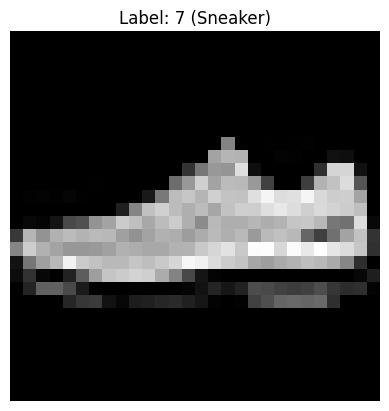

In [11]:
import requests
import gzip
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO

# Fashion MNIST 데이터셋 URL
t10k_images_url = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz'
t10k_labels_url = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz'

# 데이터 다운로드 및 압축 해제 함수
def download_and_extract(url):
    response = requests.get(url)
    with gzip.open(BytesIO(response.content), 'rb') as f:
        return np.frombuffer(f.read(), np.uint8)

# 데이터 다운로드 및 로드
t10k_images = download_and_extract(t10k_images_url)[16:].reshape(-1, 28, 28)
t10k_labels = download_and_extract(t10k_labels_url)[8:]

# 라벨 이름 정의
label_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 랜덤 이미지 선택 및 출력 함수
def get_random_image(images, labels):
    random_idx = np.random.randint(len(images))
    random_image = images[random_idx]
    random_label = labels[random_idx]
    return random_image, random_label

def show_image(image, label, label_names):
    plt.imshow(image, cmap='gray')
    plt.title(f'Label: {label} ({label_names[label]})')
    plt.axis('off')
    plt.show()

# 랜덤 이미지 선택
random_image, random_label = get_random_image(t10k_images, t10k_labels)

# 랜덤 이미지 출력
show_image(random_image, random_label, label_names)

### 6-2. 모델 서빙 API 테스트

endpoint: http://torchserve-63e62460-predictor.kbm-u-kubeflow-tutorial.svc.cluster.local/predictions/torch-model-63e62460
status_code: 200
raw response: 7


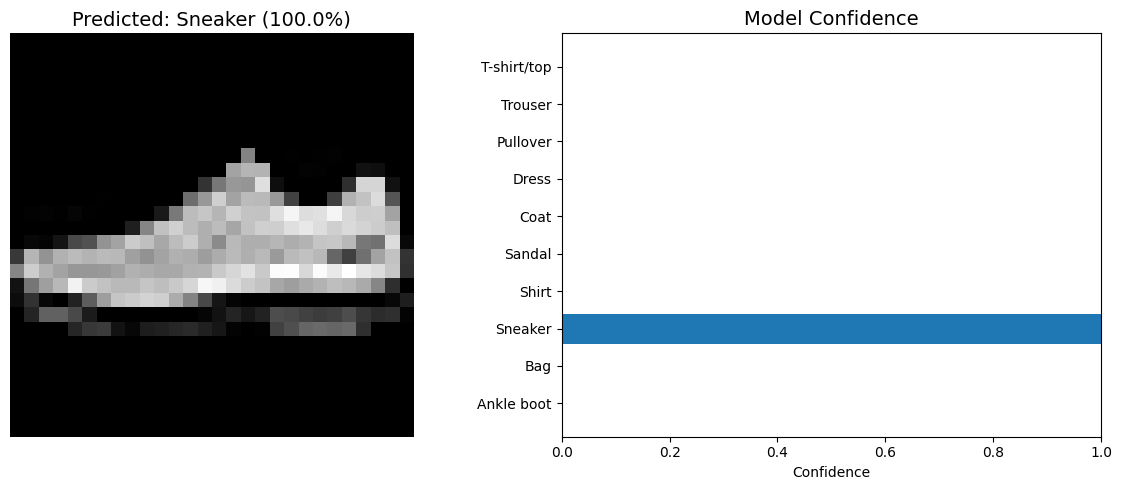

모델 추론 결과
추론된 결과는 Sneaker 이고 실제 정답은 Sneaker 입니다.
모델이 정답을 정확히 맞췄습니다.


In [25]:
import io
import os
import json
import warnings
import numpy as np
import requests
import matplotlib.pyplot as plt
from PIL import Image

# matplotlib 한글 glyph 경고 숨기기
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

KBM_NAMESPACE = os.environ["NB_PREFIX"].split("/")[2]
KUBEFLOW_HOST = os.environ["KUBEFLOW_HOST"].rstrip("/")
KUBEFLOW_USERNAME = os.environ["KUBEFLOW_USERNAME"]
KUBEFLOW_PASSWORD = os.environ["KUBEFLOW_PASSWORD"]

MODEL_NAME = f"torch-model-{TASK_UUID}"
KBM_MODEL_SERV_NAME = f"torchserve-{TASK_UUID}"

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

def get_authenticated_session():
    session = requests.Session()
    _kargs = {"verify": False} if KUBEFLOW_HOST.startswith("https") else {}

    resp = session.get(KUBEFLOW_HOST, **_kargs)
    headers = {"Content-Type": "application/x-www-form-urlencoded"}
    login_resp = session.post(
        resp.url,
        headers=headers,
        data={"login": KUBEFLOW_USERNAME, "password": KUBEFLOW_PASSWORD},
        **_kargs,
    )
    login_resp.raise_for_status()

    cookies = session.cookies.get_dict()
    if "authservice_session" not in cookies:
        raise RuntimeError(f"authservice_session 쿠키를 받지 못했습니다: {cookies}")

    return session, _kargs

def get_predictor_base_url():
    return f"http://{KBM_MODEL_SERV_NAME}-predictor.{KBM_NAMESPACE}.svc.cluster.local"
    # host = KUBEFLOW_HOST.split("://", 1)[1]

    # if host.startswith("kubeflow."):
    #     public_domain = host[len("kubeflow."):]
    # else:
    #     public_domain = host

    # return f"https://{KBM_MODEL_SERV_NAME}-predictor.{KBM_NAMESPACE}.{public_domain}"
    

def image_to_png_bytes(image):
    if isinstance(image, Image.Image):
        pil_img = image.convert("L")
    else:
        arr = np.asarray(image)
        if np.issubdtype(arr.dtype, np.floating):
            if arr.max() <= 1.0:
                arr = (arr * 255.0).clip(0, 255).astype(np.uint8)
            else:
                arr = arr.clip(0, 255).astype(np.uint8)
        else:
            arr = arr.astype(np.uint8)

        if arr.ndim == 3 and arr.shape[-1] == 1:
            arr = arr.squeeze(-1)

        pil_img = Image.fromarray(arr).convert("L")

    buf = io.BytesIO()
    pil_img.save(buf, format="PNG")
    return buf.getvalue()

def send_test_request(image, session, _kargs):
    base_url = get_predictor_base_url()
    endpoint = f"{base_url}/predictions/{MODEL_NAME}"
    print(f"endpoint: {endpoint}")

    png_bytes = image_to_png_bytes(image)

    response = session.post(
        url=endpoint,
        headers={"Content-Type": "application/octet-stream"},
        data=png_bytes,
        allow_redirects=False,
        **_kargs,
    )

    print("status_code:", response.status_code)

    try:
        return response.json()
    except ValueError:
        try:
            return int(response.text.strip())
        except Exception:
            return response.text

def normalize_scores(result):
    if isinstance(result, dict):
        if "predictions" in result:
            scores = result["predictions"]
        elif "scores" in result:
            scores = result["scores"]
        elif "probabilities" in result:
            scores = result["probabilities"]
        elif "class_id" in result:
            class_id = int(result["class_id"])
            onehot = np.zeros(len(CLASS_NAMES), dtype=float)
            onehot[class_id] = 1.0
            return onehot
        else:
            raise ValueError(f"알 수 없는 응답 형식: {result}")

    elif isinstance(result, list):
        scores = result

    elif isinstance(result, (int, np.integer, float)):
        class_id = int(result)
        onehot = np.zeros(len(CLASS_NAMES), dtype=float)
        onehot[class_id] = 1.0
        return onehot

    else:
        raise ValueError(f"지원하지 않는 응답 형식: {type(result)} / {result}")

    scores = np.array(scores, dtype=float).flatten()

    if len(scores) != len(CLASS_NAMES):
        raise ValueError(
            f"클래스 수가 맞지 않습니다. expected={len(CLASS_NAMES)}, got={len(scores)}"
        )

    if np.any(scores < 0) or np.sum(scores) <= 0 or not np.isclose(np.sum(scores), 1.0, atol=1e-3):
        exp_scores = np.exp(scores - np.max(scores))
        scores = exp_scores / np.sum(exp_scores)

    return scores

def show_inference_result(image, scores, true_label=None):
    pred_idx = int(np.argmax(scores))
    pred_name = CLASS_NAMES[pred_idx]
    pred_conf = float(scores[pred_idx]) * 100

    fig = plt.figure(figsize=(12, 5))

    # left: image
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(np.asarray(image).squeeze(), cmap="gray")
    ax1.axis("off")
    ax1.set_title(f"Predicted: {pred_name} ({pred_conf:.1f}%)", fontsize=14)

    # right: bar chart
    ax2 = fig.add_subplot(1, 2, 2)
    y = np.arange(len(CLASS_NAMES))
    ax2.barh(y, scores)
    ax2.set_yticks(y)
    ax2.set_yticklabels(CLASS_NAMES)
    ax2.invert_yaxis()
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("Confidence")
    ax2.set_title("Model Confidence", fontsize=14)

    plt.tight_layout()
    plt.show()

    print("=" * 60)
    print("모델 추론 결과")
    print("=" * 60)

    if true_label is not None:
        true_name = CLASS_NAMES[int(true_label)]
        print(f"추론된 결과는 {pred_name} 이고 실제 정답은 {true_name} 입니다.")
        if int(true_label) == pred_idx:
            print("모델이 정답을 정확히 맞췄습니다.")
        else:
            print("이번에는 정답과 다르게 추론했습니다.")
    else:
        print(f"추론된 결과는 {pred_name} 입니다.")

def run_demo(image, true_label=None):
    session, _kargs = get_authenticated_session()
    raw_result = send_test_request(image, session, _kargs)

    print("raw response:", raw_result)

    scores = normalize_scores(raw_result)
    show_inference_result(image, scores, true_label=true_label)

# 실행
run_demo(random_image, true_label=random_label if "random_label" in globals() else None)

### KServe에서 모델을 배포하고 관리하는 inferenceservices(추상화된 리소스) 조회

In [16]:
!kubectl get inferenceservices -o yaml

apiVersion: v1
items:
- apiVersion: serving.kserve.io/v1beta1
  kind: InferenceService
  metadata:
    creationTimestamp: "2026-03-17T09:12:47Z"
    finalizers:
    - inferenceservice.finalizers
    generation: 1
    name: torchserve-63e62460
    namespace: kbm-u-kubeflow-tutorial
    resourceVersion: "47922"
    uid: 9ca8bc37-745c-4c07-8d06-316931c5ba18
  spec:
    predictor:
      automountServiceAccountToken: false
      model:
        modelFormat:
          name: pytorch
        name: ""
        resources:
          limits:
            cpu: "1"
            memory: 2Gi
          requests:
            cpu: "1"
            memory: 2Gi
        runtime: fmnist-pytorch-foreground-runtime
        storageUri: pvc://test-fmnist-pvc-63e62460/fmnist_model
  status:
    address:
      url: http://torchserve-63e62460.kbm-u-kubeflow-tutorial.svc.cluster.local
    components:
      predictor:
        address:
          url: http://torchserve-63e62460-predictor.kbm-u-kubeflow-tutorial.svc.cluster.

### InferenceService에 의해 생성된 실제 모델 서빙을 수행하는 Pod 조회

In [17]:
!kubectl get po  | grep torchserve

torchserve-63e62460-predictor-00001-deployment-584df76d4d-c2qj2   3/3     Running                  0          25m
torchserve-63e62460-predictor-00001-deployment-584df76d4d-mkxpw   0/3     ContainerStatusUnknown   3          27m


### 자원 정리

In [ ]:
import subprocess
import time

def delete_resource(kind, name):
    subprocess.run(["kubectl","delete",kind,name,"-n",KBM_NAMESPACE], check=False)

    while True:
        r = subprocess.run(
            ["kubectl","get",kind,name,"-n",KBM_NAMESPACE],
            capture_output=True
        )
        if r.returncode != 0:
            break
        time.sleep(1)

print("Cleaning resources")

delete_resource("inferenceservice", KBM_MODEL_SERV_NAME)
delete_resource("servingruntime", RUNTIME_NAME)
delete_resource("pvc", PVC_NAME)

print("Cleanup done")